# Exploratory Data Analysis on Netflix Movies & TV Shows Dataset

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the Netflix Movies & TV Shows dataset using Python. The objective is to inspect, clean, analyze, and visualize the data to identify meaningful trends and patterns. Based on the analysis, business insights and recommendations are provided.

**Tools Used**: Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab

## Step 1: Load and Inspect the Dataset

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [47]:
df = pd.read_csv("NetFlix.csv")

In [48]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [49]:
df.shape

(7787, 12)

In [50]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [51]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,int64


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


### Dataset Summary

The Netflix dataset contains information about movies and TV shows available on Netflix. It includes details such as title, content type, director, cast, country, release year, rating, duration, genre, and description. The dataset contains both categorical and numerical data, with some missing values in columns like director, cast, and country. No major structural issues were observed during the initial inspection. This dataset is suitable for exploratory data analysis and visualization.

## Step 2: Data Cleaning

### Checking Missing Values Before Cleaning

In [55]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


### Filling Missing Values

In [56]:
# Fill missing values in the director column

df["director"] = df["director"].fillna("Unknown")

In [57]:
# Fill missing values in the cast column

df["cast"] = df["cast"].fillna("Not Available")

In [58]:
# Fill missing values in the country column

df["country"] = df["country"].fillna("Unknown")

In [59]:
# Fill missing values in the rating column with the most frequent rating

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [60]:
# Remove rows with missing date_added values

df.dropna(subset=["date_added"], inplace=True)

In [61]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

In [62]:
# Check missing values after cleaning

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### Data Cleaning Decisions

1. Filled missing values in the **director** column with **"Unknown"** because the director information was unavailable for many titles.
2. Filled missing values in the **cast** column with **"Not Available"** to preserve records while indicating missing information.
3. Filled missing values in the **country** column with **"Unknown"** to retain all records for country-based analysis.
4. Filled missing values in the **rating** column using the **most frequent (mode) rating**, as it is a reasonable replacement for a small number of missing values.
5. Removed rows with missing **date_added** values because they are not suitable for analyses involving the date content was added.
6. Removed duplicate records to ensure the dataset contains unique entries.

In [63]:
df.duplicated().sum()

np.int64(0)

## Step 3: Exploratory Data Analysis (EDA)

### Question 1: What is the distribution of Movies and TV Shows on Netflix?

In [64]:
# Count Movies and TV Shows

df["type"].value_counts()

,count
type,
Movie,5377
TV Show,2400


**Observation:** The dataset shows the distribution of Movies and TV Shows available on Netflix. This helps understand which type of content dominates the platform.

### Question 2: Which are the top 10 countries with the highest number of Netflix titles?

In [65]:
# Top 10 countries

df["country"].value_counts().head(10)

,count
country,
United States,2549
India,923
Unknown,506
United Kingdom,396
Japan,225
South Korea,183
Canada,177
Spain,134
France,115


**Observation:** A small number of countries contribute a large share of Netflix titles, indicating that content production is concentrated in specific regions.

### Question 3: Which content ratings are most common on Netflix?

In [66]:
# Count ratings

df["rating"].value_counts()

,count
rating,
TV-MA,2868
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


**Observation:** Certain content ratings appear much more frequently than others, suggesting Netflix targets specific audience groups more heavily.

### Question 4: How has Netflix content changed over the years?

In [67]:
# Titles released each year

df["release_year"].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,3
...,...
2017,1012
2018,1120
2019,996


**Observation:** The number of Netflix titles varies across release years, showing how content production has changed over time.

### Question 5: What are the top 10 most common genres on Netflix?

In [68]:
# Top genres

df["genres"].value_counts().head(10)

,count
genres,
Documentaries,334
Stand-Up Comedy,321
"Dramas, International Movies",320
"Comedies, Dramas, International Movies",243
"Dramas, Independent Movies, International Movies",215
Kids' TV,204
Children & Family Movies,177
"Documentaries, International Movies",172
"Children & Family Movies, Comedies",169


**Observation:** Some genres are much more common than others, indicating Netflix's stronger focus on particular types of entertainment.

## Step 4: Data Visualization

### Visualization 1: Distribution of Movies and TV Shows

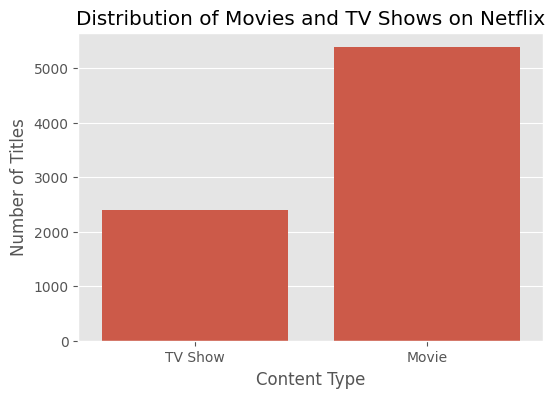

In [69]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

### Visualization 2: Number of Titles Released Each Year

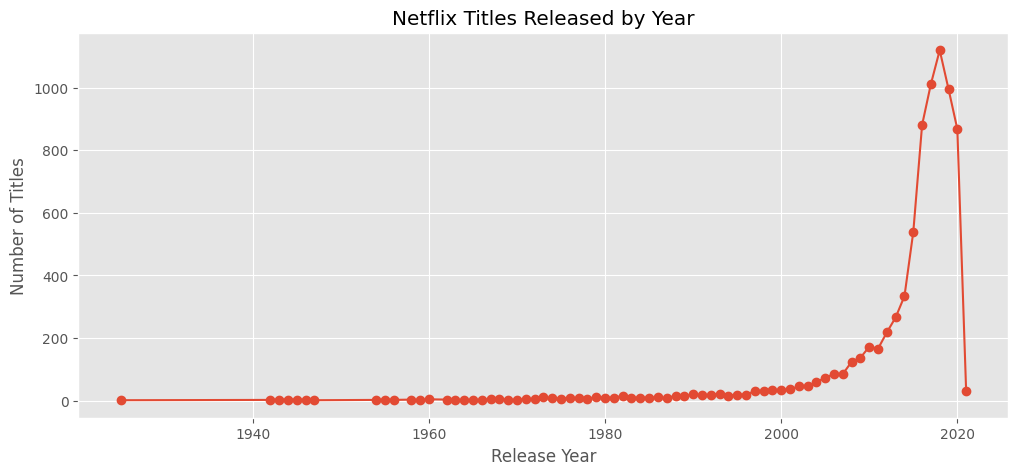

In [70]:
plt.figure(figsize=(12,5))

release_counts = df["release_year"].value_counts().sort_index()

plt.plot(release_counts.index, release_counts.values, marker="o")

plt.title("Netflix Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

### Visualization 3: Distribution of Movie Durations

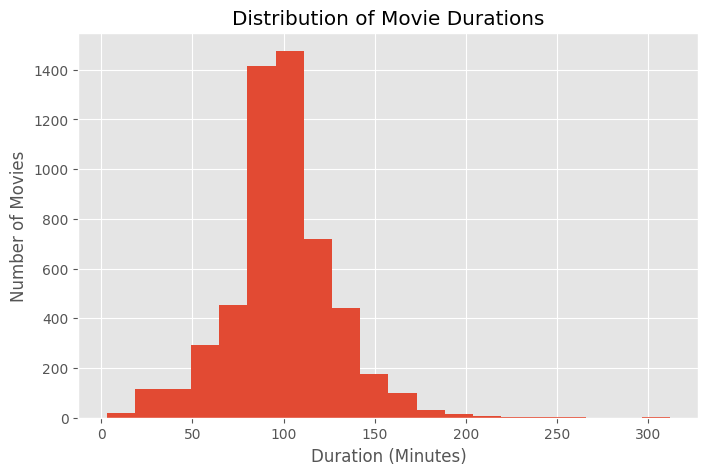

In [71]:
movies = df[df["type"] == "Movie"]

plt.figure(figsize=(8,5))

plt.hist(movies["duration"], bins=20)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

### Visualization 4: Movie Duration vs Release Year

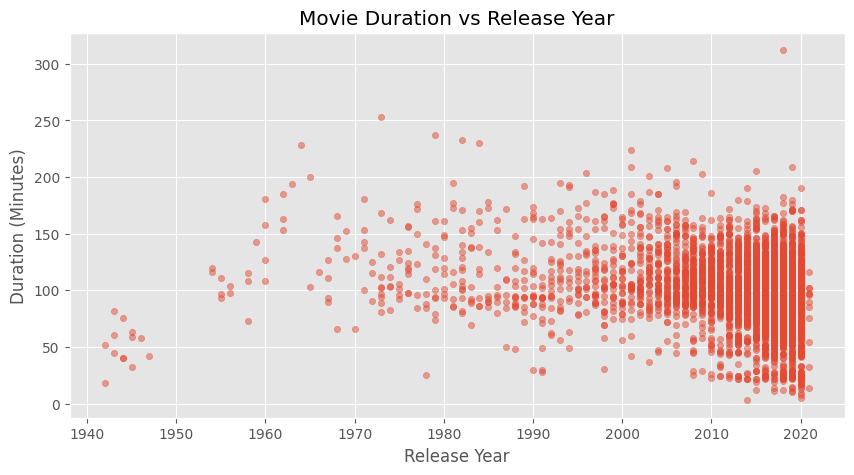

In [72]:
# Filter only movies
movies = df[df["type"] == "Movie"]

plt.figure(figsize=(10,5))

plt.scatter(
    movies["release_year"],
    movies["duration"],
    alpha=0.5,
    s = 20
)

plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

plt.show()

### Visualization 5: Distribution of Top 5 Content Ratings

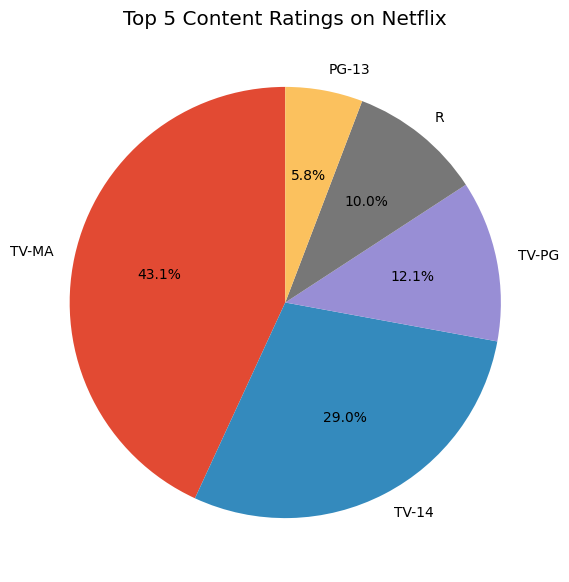

In [73]:
top_ratings = df["rating"].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(
    top_ratings,
    labels=top_ratings.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Content Ratings on Netflix")

plt.show()

### Visualization 6: Correlation Heatmap

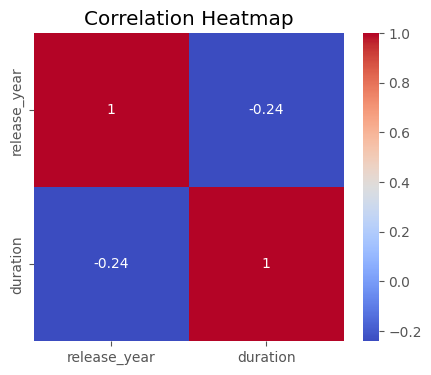

In [74]:
plt.figure(figsize=(5,4))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Step 5: Insights Report

### Business Insights

1. Movies make up a significantly larger portion of Netflix's catalog than TV Shows, indicating that Netflix has historically focused more on movie content.

2. Netflix experienced rapid content growth after 2015, with the highest number of titles being released between 2017 and 2020. This reflects the platform's aggressive global expansion during that period.

3. Most Netflix movies have durations between **80 and 120 minutes**, showing a preference for standard feature-length films.

4. TV-MA is the most common content rating, followed by TV-14, indicating that Netflix primarily targets mature and teenage audiences.

5. The weak negative correlation (-0.24) between release year and movie duration suggests that newer movies tend to be slightly shorter on average, although the relationship is not strong.

## Most Surprising Finding

The most surprising finding was the dramatic increase in the number of Netflix titles released after 2015. The platform expanded its content library very rapidly within a few years. It was also interesting to observe that most movies have a duration between 80 and 120 minutes, showing a consistent preference for standard-length films.

## Conclusion

This project successfully performed Exploratory Data Analysis on the Netflix Movies & TV Shows dataset. After cleaning the dataset, various analyses and visualizations were used to identify trends in content type, release year, duration, ratings, and genres. The findings demonstrate how data analysis can provide valuable insights that support business decisions and content strategy.

## Business Recommendations

1. Increase investment in movie production, as movies represent the majority of the Netflix catalog and continue to attract audiences.

2. Continue expanding original content in regions with lower representation to diversify the global content library.

3. Maintain a balanced mix of standard-length movies (80–120 minutes), as they appear to align with the platform's dominant content format.

4. Expand family-friendly and children's content to balance the strong focus on mature-rated titles.

5. Regularly analyze viewer preferences across genres and ratings to improve personalized recommendations and future content acquisition strategies.